# YOLO26 폐기물 분류 모델 학습 · 평가 · 테스트

| 항목 | 내용 |
|---|---|
| **모델** | YOLO26 (Ultralytics 최신) |
| **클래스** | 고철류 / 비닐 / 유리병 / 캔류 / 형광등 (5종) |
| **데이터셋** | `data/dataset/`  ·  train 6,998 / valid 1,502 / test 1,500 |
| **이미지 크기** | 1024 × 576 (원본), 학습 시 640 리사이즈 |

---
### 실행 순서
1. 환경 설치 확인  
2. 데이터셋 검증  
3. 모델 학습  
4. 학습 결과 시각화  
5. Validation 성능 평가  
6. Test 세트 평가  
7. 샘플 추론 & 시각화  
8. 모델 Export (ONNX)  

---
## 0. 환경 설치 확인

In [1]:
# 필요 패키지 설치 (최초 1회)
# !pip install ultralytics matplotlib Pillow seaborn

import importlib, subprocess, sys

REQUIRED = ["ultralytics", "matplotlib", "PIL", "seaborn", "yaml"]
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg if pkg != "PIL" else "PIL")
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  ✗ {pkg} 설치 필요 → pip install {pkg}")

import torch
print(f"\nPyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU 학습'})"
)

  ✓ ultralytics
  ✓ matplotlib
  ✓ PIL
  ✓ seaborn
  ✓ yaml

PyTorch : 2.5.1+cu121
CUDA    : True (NVIDIA GeForce RTX 4060 Ti)


In [2]:
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics version : {ultralytics.__version__}")

Ultralytics version : 8.4.27


---
## 1. 경로 설정

In [3]:
from pathlib import Path

# ── 경로 설정 ──────────────────────────────────────────────
BASE_DIR    = Path(".")                          # 노트북 위치 = waste/
DATASET_DIR = BASE_DIR / "data" / "dataset"
YAML_PATH   = DATASET_DIR / "data.yaml"
RUNS_DIR    = BASE_DIR / "runs"                  # 학습 결과 저장
MODEL_DIR   = BASE_DIR / "model"                 # 사전학습 가중치 저장
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 수정 후 — 변수로 분리하여 충돌 제거
n_train = len(list((DATASET_DIR / "train" / "images").glob("*.jpg")))
n_valid = len(list((DATASET_DIR / "valid" / "images").glob("*.jpg")))
n_test  = len(list((DATASET_DIR / "test"  / "images").glob("*.jpg")))

assert YAML_PATH.exists(), f"data.yaml 없음: {YAML_PATH}"
print(f"data.yaml  : {YAML_PATH.resolve()}")
print(f"model dir  : {MODEL_DIR.resolve()}")
print(f"train imgs : {n_train:,}장")  # ← f-string 내부 단순 변수 참조
print(f"valid imgs : {n_valid:,}장")
print(f"test  imgs : {n_test:,}장")

data.yaml  : /mnt/c/Users/Brain/github/yolo26_app/waste/data/dataset/data.yaml
model dir  : /mnt/c/Users/Brain/github/yolo26_app/waste/model
train imgs : 6,998장
valid imgs : 1,502장
test  imgs : 1,500장


---
## 2. 데이터셋 검증

In [4]:
import yaml, collections
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import random, math

# ── yaml 읽기 ──────────────────────────────────────────────
with open(YAML_PATH, encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

CLASS_NAMES = list(cfg["names"].values())
NC          = cfg["nc"]
COLORS      = plt.cm.tab10.colors

print(f"클래스 수 : {NC}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

클래스 수 : 5
  0: 고철류
  1: 비닐
  2: 유리병
  3: 캔류
  4: 형광등


In [5]:
# 한글 폰트 및 시각화 설정 
import os
import platform

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt


def set_korean_font():
    """Windows / Linux(Colab 포함) / macOS 환경에 맞춰 한글 폰트를 설정합니다."""
    system = platform.system()

    if system == "Windows":
        font_path = "c:/Windows/Fonts/malgun.ttf"
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        plt.rc("font", family=font_name)
        print(f"한글 폰트 설정: {font_name} ({font_path})")

    elif system == "Linux":
        # 1) 이미 설치된 나눔 폰트 탐색
        nanum_paths = [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/nanum/NanumGothic.ttf",
            os.path.expanduser("~/.local/share/fonts/NanumGothic.ttf"),
        ]
        font_path = next((p for p in nanum_paths if os.path.isfile(p)), None)

        # 2) 없으면 apt-get으로 설치 시도 (Colab / Ubuntu)
        if font_path is None:
            print("나눔 폰트 설치 중 (apt-get)...")
            import subprocess

            subprocess.run(
                ["apt-get", "install", "-y", "-qq", "fonts-nanum"],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
            font_path = next((p for p in nanum_paths if os.path.isfile(p)), None)

        # 3) apt-get 불가 시 직접 다운로드 (홈 디렉터리에 저장)
        if font_path is None:
            print("나눔 폰트 다운로드 중...")
            import urllib.request

            font_dir = os.path.expanduser("~/.local/share/fonts")
            os.makedirs(font_dir, exist_ok=True)
            font_path = os.path.join(font_dir, "NanumGothic.ttf")
            url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
            urllib.request.urlretrieve(url, font_path)

        if font_path and os.path.isfile(font_path):
            fm.fontManager.addfont(font_path)
            font_name = fm.FontProperties(fname=font_path).get_name()
            plt.rc("font", family=font_name)
            print(f"한글 폰트 설정: {font_name} ({font_path})")
        else:
            print("경고: 한글 폰트를 설정할 수 없습니다.")

    elif system == "Darwin":  # macOS
        plt.rc("font", family="AppleGothic")
        print("한글 폰트 설정: AppleGothic")

    else:
        print("지원되지 않는 OS:", system)


# ── 폰트 함수 호출 ──────────────────────────────────────────
set_korean_font()

# 폰트 캐시 갱신 (커널 재시작 없이도 반영)
import matplotlib
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

print("시각화 설정 완료")


한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
시각화 설정 완료


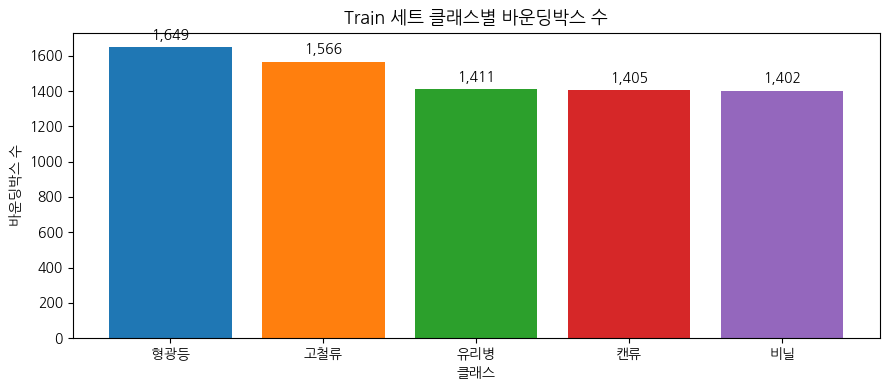

총 bbox: 7433


In [6]:
# ── 클래스별 이미지 수 분포 (train 기준) ───────────────────
train_img_dir = DATASET_DIR / "train" / "images"
train_lbl_dir = DATASET_DIR / "train" / "labels"

cls_count = collections.Counter()
for lbl in train_lbl_dir.glob("*.txt"):
    lines = lbl.read_text(encoding="utf-8").strip().splitlines()
    for line in lines:
        if line.strip():
            cls_id = int(line.split()[0])
            cls_count[CLASS_NAMES[cls_id]] += 1

fig, ax = plt.subplots(figsize=(9, 4))
names = [n for n, _ in cls_count.most_common()]
vals  = [v for _, v in cls_count.most_common()]
bars  = ax.bar(names, vals, color=[COLORS[i] for i in range(len(names))])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("Train 세트 클래스별 바운딩박스 수", fontsize=13)
ax.set_ylabel("바운딩박스 수")
ax.set_xlabel("클래스")
plt.tight_layout()
plt.show()
print("총 bbox:", sum(vals))

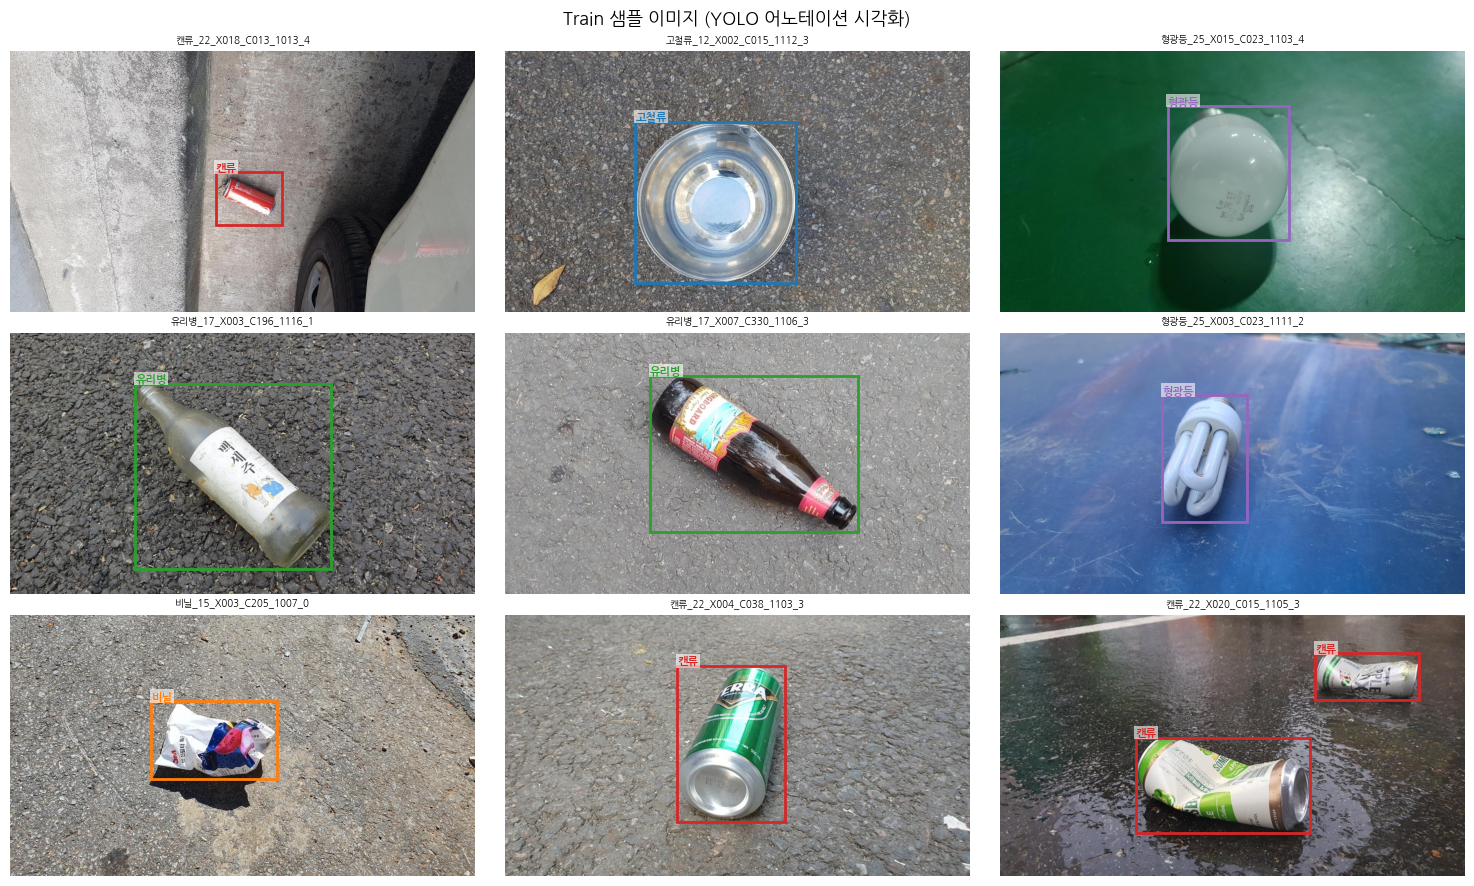

In [7]:
# ── 샘플 이미지 + 바운딩박스 시각화 (train에서 랜덤 9장) ───
sample_imgs = random.sample(sorted(train_img_dir.glob("*.jpg")), 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    img  = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)

    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cid, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:5])
            x1 = (cx - bw/2) * W
            y1 = (cy - bh/2) * H
            rect = mpatches.Rectangle(
                (x1, y1), bw*W, bh*H,
                linewidth=2, edgecolor=COLORS[cid], facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 4, CLASS_NAMES[cid],
                    color=COLORS[cid], fontsize=8, fontweight="bold",
                    bbox=dict(facecolor="white", alpha=0.6, pad=1, edgecolor="none"))
    ax.axis("off")
    ax.set_title(img_path.stem[:30], fontsize=7)

plt.suptitle("Train 샘플 이미지 (YOLO 어노테이션 시각화)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. YOLO26 모델 학습

> **모델 크기 선택 가이드**
> | 모델 | mAP50-95 | 속도(ms) | 추천 상황 |
> |---|---|---|---|
> | yolo26n | 40.9 | 빠름 | 엣지 디바이스, 실시간 우선 |
> | yolo26s | 48.0 | 중간 | 균형형 |
> | yolo26m | 52.5 | 중간 | **실시간 감지 시스템 권장** |
> | yolo26l | 55.3 | 느림 | 정확도 우선 |
> | yolo26x | 57.5 | 가장느림 | 최고 정확도 |

In [ ]:
# ── 학습 하이퍼파라미터 설정 ────────────────────────────────
MODEL_SIZE  = "m"       # n / s / m / l / x  변경 가능
PRETRAINED  = str(MODEL_DIR / f"yolo26{MODEL_SIZE}.pt")  # model/ 폴더에 저장
EPOCHS      = 100
IMG_SIZE    = 640       # YOLO 표준 입력 크기
BATCH_SIZE  = 16        # GPU VRAM 부족 시 8로 줄이기
WORKERS     = 4

# ※ 절대경로 사용 필수 — 상대경로이면 Ultralytics 가 앞에 runs/detect/ 를 붙임
PROJECT  = str((RUNS_DIR / "waste_yolo26").resolve())
EXP_NAME = f"yolo26{MODEL_SIZE}_ep{EPOCHS}"

print(f"사전학습 모델 : {PRETRAINED}")
print(f"학습 Epoch   : {EPOCHS}")
print(f"이미지 크기  : {IMG_SIZE}")
print(f"배치 크기    : {BATCH_SIZE}")
print(f"결과 저장    : {PROJECT}/{EXP_NAME}")


사전학습 모델 : model/yolo26m.pt
학습 Epoch   : 20
이미지 크기  : 640
배치 크기    : 32
결과 저장    : runs/waste_yolo26/yolo26m_ep20


In [9]:
# ── 모델 로드 (가중치가 없으면 model/ 폴더로 다운로드) ─────
from pathlib import Path
import shutil

pretrained_path = Path(PRETRAINED)
if not pretrained_path.exists():
    from ultralytics.utils.downloads import attempt_download_asset
    print(f"가중치 다운로드 중 → {pretrained_path}")
    tmp = Path(attempt_download_asset(pretrained_path.name))
    if tmp.resolve() != pretrained_path.resolve():
        shutil.move(str(tmp), str(pretrained_path))
    print(f"저장 완료 : {pretrained_path.resolve()}")
else:
    print(f"기존 가중치 사용 : {pretrained_path.resolve()}")

model = YOLO(PRETRAINED)
print(model.info())

기존 가중치 사용 : /mnt/c/Users/Brain/github/yolo26_app/waste/model/yolo26m.pt
YOLO26m summary: 280 layers, 21,896,248 parameters, 0 gradients, 75.4 GFLOPs
(280, 21896248, 0, 75.3975296)


In [ ]:
# ── 학습 시작 (재개 지원 + Epoch별 점수 자동 저장) ─────────
import json as _json, torch
from pathlib import Path
from ultralytics import YOLO

exp_dir   = Path(PROJECT) / EXP_NAME
last_pt   = exp_dir / "weights" / "last.pt"
epoch_log = exp_dir / "epoch_scores.json"   # Epoch별 점수 저장 파일

# ── 재개 여부 자동 판단 ─────────────────────────────────────
if last_pt.exists():
    print(f"[RESUME] 체크포인트 감지 → {last_pt}")
    print("         이어서 학습합니다.")
    _resume = True
else:
    print("[NEW] 새로 학습을 시작합니다.")
    _resume = False

# ── 기존 Epoch 점수 불러오기 (재개 시 이어 쓰기) ────────────
_epoch_scores = []
if _resume and epoch_log.exists():
    _epoch_scores = _json.loads(epoch_log.read_text(encoding="utf-8"))
    print(f"         기존 기록 {len(_epoch_scores)} Epoch 로드 완료")

# ── Epoch별 점수 저장 콜백 ──────────────────────────────────
def _on_fit_epoch_end(trainer):
    """매 Epoch 학습+검증 완료 후 호출 → JSON에 즉시 저장"""
    entry = {"epoch": trainer.epoch + 1}

    # train loss
    if getattr(trainer, "loss_items", None) is not None:
        li = trainer.loss_items
        entry["box_loss"] = round(float(li[0]), 6)
        entry["cls_loss"] = round(float(li[1]), 6)
        entry["dfl_loss"] = round(float(li[2]), 6)

    # val metrics  (trainer.metrics 는 dict: {"metrics/mAP50(B)": ...})
    m = getattr(trainer, "metrics", {}) or {}
    entry["val_mAP50"]     = round(float(m.get("metrics/mAP50(B)",    0)), 6)
    entry["val_mAP50_95"]  = round(float(m.get("metrics/mAP50-95(B)", 0)), 6)
    entry["val_precision"] = round(float(m.get("metrics/precision(B)",0)), 6)
    entry["val_recall"]    = round(float(m.get("metrics/recall(B)",   0)), 6)
    entry["fitness"]       = round(float(m.get("fitness",             0)), 6)

    _epoch_scores.append(entry)
    epoch_log.parent.mkdir(parents=True, exist_ok=True)
    epoch_log.write_text(
        _json.dumps(_epoch_scores, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    ep    = entry["epoch"]
    mAP   = entry["val_mAP50"]
    bloss = entry.get("box_loss", "-")
    print(f"  [Epoch {ep:>3}] box_loss={bloss:.4f}  mAP50={mAP:.4f}  → {epoch_log.name} 저장")

# ── 모델 준비 ───────────────────────────────────────────────
if _resume:
    # resume=True 시 last.pt 에서 모든 설정 자동 복원
    _model_resume = YOLO(str(last_pt))
    _model_resume.add_callback("on_fit_epoch_end", _on_fit_epoch_end)
    print("\n학습 재개 중...")
    train_results = _model_resume.train(resume=True)
    model = _model_resume          # 이후 셀에서 model 변수 유지
else:
    # 신규 학습: cell 13 에서 로드한 model 에 콜백 추가
    model.add_callback("on_fit_epoch_end", _on_fit_epoch_end)
    print("\n학습 시작...")
    train_results = model.train(
        data         = str(YAML_PATH),
        epochs       = EPOCHS,
        imgsz        = IMG_SIZE,
        batch        = BATCH_SIZE,
        workers      = WORKERS,
        project      = PROJECT,
        name         = EXP_NAME,
        exist_ok     = True,
        patience     = 2,
        optimizer    = "AdamW",
        lr0          = 0.001,
        lrf          = 0.01,
        momentum     = 0.937,
        weight_decay = 0.0005,
        warmup_epochs= 3,
        mosaic       = 1.0,
        flipud       = 0.0,
        fliplr       = 0.5,
        degrees      = 10.0,
        translate    = 0.1,
        scale        = 0.5,
        device       = 0 if torch.cuda.is_available() else "cpu",
        verbose      = True,
    )

print(f"\n학습 완료!  Epoch별 점수 저장: {epoch_log}")


[NEW] 새로 학습을 시작합니다.

학습 시작...
Ultralytics 8.4.27 🚀 Python-3.11.14 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=model/yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26m_ep20, nbs=64, nms=False, opset=None, optimize=False, optimizer=

---
## 4. 학습 결과 시각화

In [ ]:
import pandas as pd

# ── exp_dir 탐색 (절대경로 우선, 없으면 runs/ 하위 재귀 탐색) ─
def _find_exp_dir(project: str, exp_name: str):
    """
    1) {project}/{exp_name}  직접 확인
    2) runs/ 하위 전체에서 {exp_name} 폴더 재귀 탐색 (경로 불일치 대비)
    """
    # 1순위: 지정 경로
    p = pathlib.Path(project) / exp_name
    if (p / "results.csv").exists():
        return p

    # 2순위: RUNS_DIR 하위 재귀 탐색
    for candidate in RUNS_DIR.rglob(exp_name):
        if (candidate / "results.csv").exists():
            print(f"[INFO] exp_dir 자동 탐색 성공: {candidate}")
            return candidate

    # 3순위: waste/runs/ 하위 전체 탐색 (PROJECT 경로와 무관)
    waste_runs = BASE_DIR / "runs"
    for candidate in waste_runs.rglob(exp_name):
        if (candidate / "results.csv").exists():
            print(f"[INFO] exp_dir 자동 탐색 성공: {candidate}")
            return candidate

    return None

import pathlib
exp_dir  = _find_exp_dir(PROJECT, EXP_NAME)
assert exp_dir is not None, (
    f"results.csv 를 찾을 수 없습니다.\n"
    f"  지정 경로  : {Path(PROJECT) / EXP_NAME}\n"
    f"  탐색 경로  : {BASE_DIR / 'runs'} 하위 재귀\n"
    f"  학습이 완료됐는지 확인하거나 PROJECT/EXP_NAME 을 확인하세요."
)

csv_path = exp_dir / "results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(f"exp_dir  : {exp_dir}")
print(f"총 Epoch : {len(df)}")
print()
print(df.tail(5).to_string(index=False))


In [ ]:
# ── Loss & mAP 곡선 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

plots = [
    ("train/box_loss",  "val/box_loss",  "Box Loss"),
    ("train/cls_loss",  "val/cls_loss",  "Class Loss"),
    ("train/dfl_loss",  "val/dfl_loss",  "DFL Loss"),
    ("metrics/precision(B)", None,       "Precision"),
    ("metrics/recall(B)",    None,       "Recall"),
    ("metrics/mAP50(B)",     "metrics/mAP50-95(B)", "mAP"),
]

epochs_range = df["epoch"] if "epoch" in df.columns else range(len(df))

for ax, (col_train, col_val, title) in zip(axes.flatten(), plots):
    if col_train in df.columns:
        ax.plot(epochs_range, df[col_train], label="train" if col_val else col_train.split("/")[-1], color="steelblue")
    if col_val and col_val in df.columns:
        ax.plot(epochs_range, df[col_val], label="val" if col_train.startswith("train") else col_val.split("/")[-1],
                color="tomato", linestyle="--")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("YOLO26 학습 곡선", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(exp_dir / "training_curves.png", dpi=150)
plt.show()

In [ ]:
# ── Confusion Matrix, F1 곡선 등 Ultralytics 자동 생성 이미지 표시 ──
auto_imgs = [
    exp_dir / "confusion_matrix_normalized.png",
    exp_dir / "F1_curve.png",
    exp_dir / "PR_curve.png",
    exp_dir / "results.png",
]

exist_imgs = [p for p in auto_imgs if p.exists()]
if exist_imgs:
    n = len(exist_imgs)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    for ax, p in zip(axes, exist_imgs):
        ax.imshow(plt.imread(p))
        ax.set_title(p.name, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("자동 생성 이미지를 찾을 수 없습니다.")

---
## 5. Validation 성능 평가

In [ ]:
# 최고 성능 가중치(best.pt) 로드
best_weights = exp_dir / "weights" / "best.pt"
assert best_weights.exists(), f"best.pt 없음: {best_weights}"

model_best = YOLO(str(best_weights))
print(f"best.pt 로드 완료: {best_weights}")

In [ ]:
# ── Validation 평가 ─────────────────────────────────────────
val_metrics = model_best.val(
    data    = str(YAML_PATH),
    split   = "val",
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    verbose = True,
)

print("\n=== Validation 결과 ===")
print(f"  mAP50      : {val_metrics.box.map50:.4f}")
print(f"  mAP50-95   : {val_metrics.box.map:.4f}")
print(f"  Precision  : {val_metrics.box.mp:.4f}")
print(f"  Recall     : {val_metrics.box.mr:.4f}")

In [ ]:
# ── 클래스별 AP 시각화 ──────────────────────────────────────
ap50_per_cls = val_metrics.box.ap50        # ndarray (NC,)
ap_per_cls   = val_metrics.box.ap          # ndarray (NC,)  mAP50-95

x = range(NC)
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar([i - width/2 for i in x], ap50_per_cls,  width, label="AP50",     color="steelblue")
b2 = ax.bar([i + width/2 for i in x], ap_per_cls,    width, label="AP50-95",  color="tomato", alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Average Precision")
ax.set_title("클래스별 AP (Validation)", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(exp_dir / "val_ap_per_class.png", dpi=150)
plt.show()

---
## 6. Test 세트 최종 평가

In [ ]:
# ── Test 평가 ───────────────────────────────────────────────
test_metrics = model_best.val(
    data    = str(YAML_PATH),
    split   = "test",
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    verbose = True,
)

print("\n=== Test 결과 ===")
print(f"  mAP50      : {test_metrics.box.map50:.4f}")
print(f"  mAP50-95   : {test_metrics.box.map:.4f}")
print(f"  Precision  : {test_metrics.box.mp:.4f}")
print(f"  Recall     : {test_metrics.box.mr:.4f}")

In [ ]:
# ── Val vs Test 비교표 ──────────────────────────────────────
summary = pd.DataFrame({
    "Split":    ["Validation", "Test"],
    "mAP50":    [val_metrics.box.map50,  test_metrics.box.map50],
    "mAP50-95": [val_metrics.box.map,    test_metrics.box.map],
    "Precision":[val_metrics.box.mp,     test_metrics.box.mp],
    "Recall":   [val_metrics.box.mr,     test_metrics.box.mr],
})
display(summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
metrics_cols = ["mAP50", "mAP50-95", "Precision", "Recall"]
x = range(len(metrics_cols))
w = 0.3
ax.bar([i-w/2 for i in x], summary.loc[0, metrics_cols], w, label="Validation", color="steelblue")
ax.bar([i+w/2 for i in x], summary.loc[1, metrics_cols], w, label="Test",       color="tomato", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.05)
ax.set_title("Validation vs Test 성능 비교", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. 샘플 추론 & 결과 시각화

In [ ]:
# ── Test 이미지에서 랜덤 12장 추론 ─────────────────────────
test_img_dir = DATASET_DIR / "test" / "images"
sample_paths = random.sample(sorted(test_img_dir.glob("*.jpg")), 12)

results = model_best.predict(
    source     = [str(p) for p in sample_paths],
    imgsz      = IMG_SIZE,
    conf       = 0.25,      # 신뢰도 임계값
    iou        = 0.45,      # NMS IoU 임계값
    verbose    = False,
)
print(f"{len(results)}장 추론 완료")

In [ ]:
# ── 추론 결과 시각화 ────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, result in zip(axes.flatten(), results):
    img = result.orig_img[:, :, ::-1]   # BGR → RGB
    ax.imshow(img)

    boxes  = result.boxes
    if boxes is not None and len(boxes):
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cid  = int(box.cls[0].cpu())
            conf = float(box.conf[0].cpu())
            color = COLORS[cid % len(COLORS)]
            rect = mpatches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f"{CLASS_NAMES[cid]} {conf:.2f}",
                    color="white", fontsize=8, fontweight="bold",
                    bbox=dict(facecolor=color, alpha=0.7, pad=2, edgecolor="none"))
    ax.axis("off")
    ax.set_title(Path(result.path).stem[:25], fontsize=7)

plt.suptitle("Test 추론 결과 (conf≥0.25)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(exp_dir / "test_predictions.png", dpi=150)
plt.show()

In [ ]:
# ── 클래스별 탐지 신뢰도 분포 ──────────────────────────────
from collections import defaultdict
conf_by_cls = defaultdict(list)

# test 전체 추론
all_results = model_best.predict(
    source  = str(test_img_dir),
    imgsz   = IMG_SIZE,
    conf    = 0.1,
    verbose = False,
    stream  = True,
)
for r in all_results:
    if r.boxes is not None:
        for box in r.boxes:
            cid  = int(box.cls[0].cpu())
            conf = float(box.conf[0].cpu())
            conf_by_cls[CLASS_NAMES[cid]].append(conf)

fig, axes = plt.subplots(1, NC, figsize=(16, 4), sharey=True)
for ax, cls_name in zip(axes, CLASS_NAMES):
    data = conf_by_cls.get(cls_name, [])
    if data:
        ax.hist(data, bins=20, color="steelblue", alpha=0.8, edgecolor="white")
        ax.axvline(0.25, color="tomato", linestyle="--", linewidth=1.5, label="conf=0.25")
        ax.set_title(f"{cls_name}\n(n={len(data):,})", fontsize=10)
    else:
        ax.set_title(f"{cls_name}\n(탐지 없음)", fontsize=10)
    ax.set_xlabel("Confidence")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("Count")
axes[-1].legend(fontsize=8)
plt.suptitle("Test 세트 클래스별 탐지 신뢰도 분포", fontsize=13)
plt.tight_layout()
plt.savefig(exp_dir / "test_conf_distribution.png", dpi=150)
plt.show()

---
## 8. 모델 Export (ONNX / TensorRT)

실시간 감지 시스템 배포를 위해 최적화된 포맷으로 변환합니다.

In [ ]:
# ── ONNX Export (CPU/GPU 범용) ──────────────────────────────
onnx_path = model_best.export(
    format  = "onnx",
    imgsz   = IMG_SIZE,
    half    = False,     # FP16: GPU 전용 True
    dynamic = False,     # 고정 배치사이즈
    simplify= True,
)
print(f"ONNX 저장 완료 → {onnx_path}")

In [ ]:
# ── TensorRT Export (NVIDIA GPU 전용, 최고 속도) ────────────
# ※ TensorRT 설치 필요: pip install tensorrt
# trt_path = model_best.export(
#     format = "engine",
#     imgsz  = IMG_SIZE,
#     half   = True,       # FP16으로 속도 향상
#     device = 0,
# )
# print(f"TensorRT 저장 완료 → {trt_path}")
print("TensorRT export 는 위 주석 해제 후 실행")

---
## 9. 최종 요약

In [ ]:
print("=" * 55)
print("  YOLO26 폐기물 분류 모델 학습 완료 요약")
print("=" * 55)
print(f"  모델        : {PRETRAINED}")
print(f"  학습 Epoch  : {EPOCHS}")
print(f"  가중치      : {best_weights}")
print()
print("  [ Validation ]")
print(f"    mAP50     : {val_metrics.box.map50:.4f}")
print(f"    mAP50-95  : {val_metrics.box.map:.4f}")
print(f"    Precision : {val_metrics.box.mp:.4f}")
print(f"    Recall    : {val_metrics.box.mr:.4f}")
print()
print("  [ Test ]")
print(f"    mAP50     : {test_metrics.box.map50:.4f}")
print(f"    mAP50-95  : {test_metrics.box.map:.4f}")
print(f"    Precision : {test_metrics.box.mp:.4f}")
print(f"    Recall    : {test_metrics.box.mr:.4f}")
print()
print(f"  결과 폴더   : {exp_dir}")
print("=" * 55)